In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

# helper functions
from src.utils import preprocess_image

# ensure the model module is fresh (reload if already imported)
import importlib
import src.model
importlib.reload(src.model)
from src.model import build_model

In [2]:
pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.3/351.2 MB 9.8 MB/s eta 0:00:36
   ---------------------------------------- 3.9/351.2 MB 11.1 MB/s eta 0:00:32
    --------------------------------------- 6.6/351.2 MB 11.8 MB/s eta 0:00:30
   - -------------------------------------- 8.9/351.2 MB 11.7 MB/s eta 0:00:30
   - -------------------------------------- 11.3/351.2 MB 11.6 MB/s eta 0:00:30
   - -------------------------------------- 13.9/351.2 MB 11.7 MB/s eta 0:00:29
   - -------------------------------------- 16.8/351.2 MB 12.0 MB/s eta 0:00:28
   -- ------------------------------------- 19.4/351.2 MB 12.1 MB/s eta 0:00:28
   -- ------------------------------------- 22.3/351.2 MB 12.3 MB/s eta 0:00:27
   -- ------------------------------------- 24.9/351.2 MB 12.3 MB/s eta 0:00:27
   --- ------------------------------------ 27.8/351.2 MB 12.4 MB/s eta 0:00:27
   --- ------------------------------------ 30.7/351.2

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [4]:
pip install datasets

   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 527.0/527.0 kB 5.5 MB/s  0:00:00
   ---------------------------------------- 0.0/625.2 kB ? eta -:--:--
   ---------------------------------------- 625.2/625.2 kB 5.1 MB/s  0:00:00
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ------------------------- -------------- 2.4/3.7 MB 12.4 MB/s eta 0:00:01
   ---------------------------------------- 3.7/3.7 MB 10.9 MB/s  0:00:00

   ------ --------------------------------- 1/6 [hf-xet]
  Attempting uninstall: dill
   ------ --------------------------------- 1/6 [hf-xet]
    Found existing installation: dill 0.4.0
   ------ --------------------------------- 1/6 [hf-xet]
   ------------- -------------------------- 2/6 [dill]
    Uninstalling dill-0.4.0:
   ------------- -------------------------- 2/6 [dill]
   ------------- -------------------------- 2/6 [dill]
      Successfully uninstalled dill-0.4.0
   

In [1]:
import sys
import os

project_path = r"D:\AN-1469_Software\AN-1469"

os.chdir(project_path)
sys.path.insert(0, project_path)

print("Now working in:", os.getcwd())

Now working in: D:\AN-1469_Software\AN-1469


In [3]:
dataset = load_dataset("daniel3303/StoryReasoning")

dataset

DatasetDict({
    train: Dataset({
        features: ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'],
        num_rows: 3552
    })
    test: Dataset({
        features: ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'],
        num_rows: 626
    })
})

In [4]:
images = []
labels = []

# define target size (match config.yaml or your desired resize)
size = 224  # e.g. config["dataset"]["image_size"]

for story in dataset["train"]:
    story_images = story["images"]

    # make sure we don't index past the available images
    for pos in range(min(5, len(story_images))):
        images.append(preprocess_image(story_images[pos], size))
        labels.append(pos)

# convert lists to arrays for sklearn and TensorFlow
# use float32 to cut memory footprint (default is float64)
images = np.array(images, dtype=np.float32)
labels = np.array(labels)

In [6]:
print("Dataset size:", len(images))

unique, counts = np.unique(labels, return_counts=True)

for u, c in zip(unique, counts):
    print("Class", u+1, ":", c)

Dataset size: 17760
Class 1 : 3552
Class 2 : 3552
Class 3 : 3552
Class 4 : 3552
Class 5 : 3552


In [7]:
# make sure data are numpy arrays in case cell order was changed
# use float32 dtype to avoid huge allocation

X_train, X_val, y_train, y_val = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 14208
Validation samples: 3552


In [8]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(32)


Epoch 1/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 345s 744ms/step - accuracy: 0.2016 - loss: 1.6100 - val_accuracy: 0.2044 - val_loss: 1.6093
Epoch 2/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 425s 958ms/step - accuracy: 0.1933 - loss: 1.6097 - val_accuracy: 0.2050 - val_loss: 1.6094
Epoch 3/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 323s 728ms/step - accuracy: 0.1976 - loss: 1.6101 - val_accuracy: 0.2066 - val_loss: 1.6092
Epoch 4/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 618s 1s/step - accuracy: 0.1988 - loss: 1.6097 - val_accuracy: 0.2044 - val_loss: 1.6094
Epoch 5/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 321s 724ms/step - accuracy: 0.1993 - loss: 1.6098 - val_accuracy: 0.2044 - val_loss: 1.6094
Epoch 6/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 745s 2s/step - accuracy: 0.1963 - loss: 1.6097 - val_accuracy: 0.2044 - val_loss: 1.6093
Epoch 7/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 692s 2s/step - accuracy: 0.1964 - loss: 1.6097 - val_accuracy: 0.2044 - val_loss: 1.6094
Epoch 8/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 329s 742ms/step - accuracy: 0.1977 - loss: 1

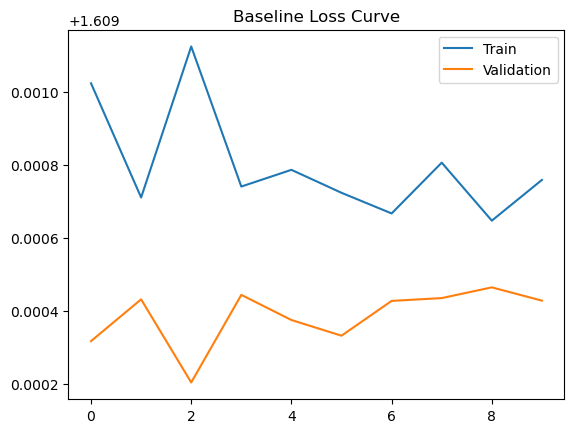

In [7]:
results = []

model = build_model(
    filters=[32,64,128],
    kernel_size=3,
    dropout=0.3,
    attention_units=128,
    batch_norm=False
)

# compile the model before fitting
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]
val_acc = history.history["val_accuracy"][-1]

results.append({
    "Experiment":"Baseline",
    "Modification":"None",
    "Train Loss":train_loss,
    "Validation Loss":val_loss,
    "Validation Accuracy":val_acc

})
plt.plot(history.history["loss"], label="Train")
plt.title("Baseline Loss Curve")
plt.plot(history.history["val_loss"], label="Validation")
plt.legend()
plt.show()

Epoch 1/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 308s 687ms/step - accuracy: 0.2012 - loss: 1.6099 - val_accuracy: 0.2044 - val_loss: 1.6094
Epoch 2/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 387s 871ms/step - accuracy: 0.1931 - loss: 1.6097 - val_accuracy: 0.2047 - val_loss: 1.6093
Epoch 3/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 384s 865ms/step - accuracy: 0.1997 - loss: 1.6099 - val_accuracy: 0.2041 - val_loss: 1.6098
Epoch 4/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 329s 741ms/step - accuracy: 0.2019 - loss: 1.6098 - val_accuracy: 0.1982 - val_loss: 1.6094
Epoch 5/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 345s 777ms/step - accuracy: 0.1962 - loss: 1.6099 - val_accuracy: 0.2044 - val_loss: 1.6093
Epoch 6/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 541s 1s/step - accuracy: 0.1959 - loss: 1.6096 - val_accuracy: 0.2044 - val_loss: 1.6094
Epoch 7/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 841s 2s/step - accuracy: 0.1985 - loss: 1.6096 - val_accuracy: 0.2044 - val_loss: 1.6094
Epoch 8/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1127s 3s/step - accuracy: 0.1983 - loss: 1

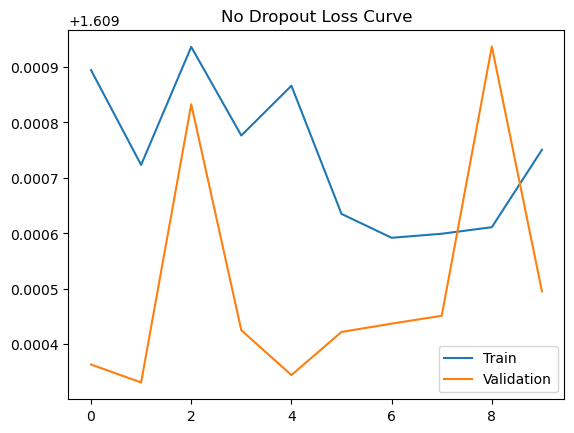

In [8]:
model = build_model(
    filters=[32,64,128],
    kernel_size=3,
    dropout=0,
    attention_units=128,
    batch_norm=False
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

results.append({
    "Experiment":"No Dropout",
    "Modification":"Remove Dropout",
    "Train Loss":history.history["loss"][-1],
    "Validation Loss":history.history["val_loss"][-1],
    "Validation Accuracy":history.history["val_accuracy"][-1]
})

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])
plt.title("No Dropout Loss Curve")
plt.legend(["Train","Validation"])
plt.show()

In [ ]:
model = build_model(
    filters=[64,128,256],
    kernel_size=3,
    dropout=0.3,
    attention_units=128,
    batch_norm=False
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)


Epoch 1/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 2460s 6s/step - accuracy: 0.1985 - loss: 1.6098 - val_accuracy: 0.2044 - val_loss: 1.6093
Epoch 2/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1874s 4s/step - accuracy: 0.1949 - loss: 1.6097 - val_accuracy: 0.2044 - val_loss: 1.6093
Epoch 3/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1826s 4s/step - accuracy: 0.2007 - loss: 1.6098 - val_accuracy: 0.2044 - val_loss: 1.6094
Epoch 4/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1938s 4s/step - accuracy: 0.1993 - loss: 1.6101 - val_accuracy: 0.2044 - val_loss: 1.6094
Epoch 5/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1904s 4s/step - accuracy: 0.2018 - loss: 1.6098 - val_accuracy: 0.2044 - val_loss: 1.6094
Epoch 6/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1890s 4s/step - accuracy: 0.1974 - loss: 1.6097 - val_accuracy: 0.2044 - val_loss: 1.6094
Epoch 7/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1985s 4s/step - accuracy: 0.2014 - loss: 1.6097 - val_accuracy: 0.2024 - val_loss: 1.6093
Epoch 8/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1884s 4s/step - accuracy: 0.1935 - loss: 1.6097 -

NameError: name 'results' is not defined

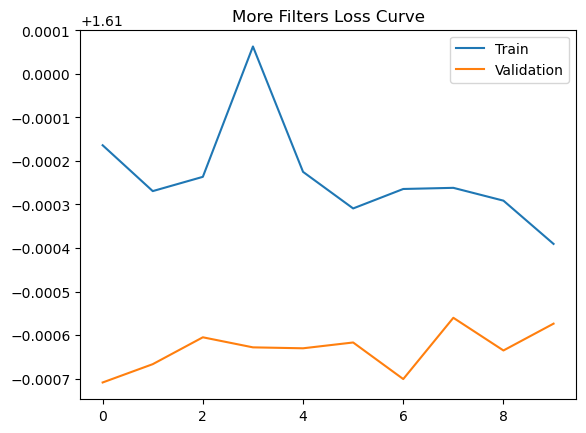

In [10]:
results = []

results.append({
    "Experiment":"More Filters",
    "Modification":"Increase CNN filters",
    "Train Loss":history.history["loss"][-1],
    "Validation Loss":history.history["val_loss"][-1],
    "Validation Accuracy":history.history["val_accuracy"][-1]
})



plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("More Filters Loss Curve")
plt.legend(["Train","Validation"])
plt.show()

Epoch 1/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 662s 1s/step - accuracy: 0.2005 - loss: 1.6100 - val_accuracy: 0.2044 - val_loss: 1.6094
Epoch 2/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 629s 1s/step - accuracy: 0.1935 - loss: 1.6097 - val_accuracy: 0.2041 - val_loss: 1.6094
Epoch 3/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 649s 1s/step - accuracy: 0.1943 - loss: 1.6097 - val_accuracy: 0.2044 - val_loss: 1.6094
Epoch 4/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 648s 1s/step - accuracy: 0.1975 - loss: 1.6100 - val_accuracy: 0.2041 - val_loss: 1.6097
Epoch 5/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 588s 1s/step - accuracy: 0.1986 - loss: 1.6101 - val_accuracy: 0.2044 - val_loss: 1.6094
Epoch 6/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 581s 1s/step - accuracy: 0.1957 - loss: 1.6097 - val_accuracy: 0.2044 - val_loss: 1.6094
Epoch 7/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 568s 1s/step - accuracy: 0.1979 - loss: 1.6097 - val_accuracy: 0.2044 - val_loss: 1.6094
Epoch 8/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 585s 1s/step - accuracy: 0.1990 - loss: 1.6098 - val_accu

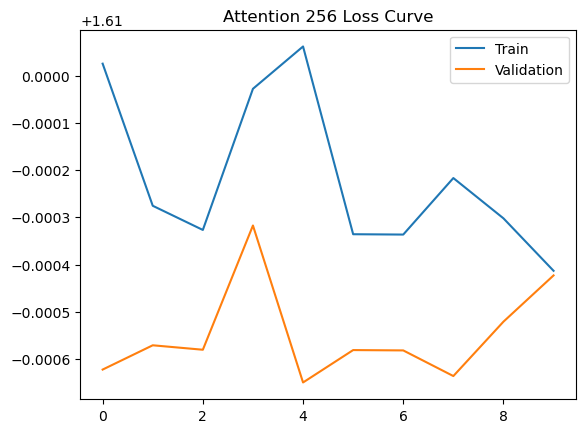

In [11]:
model = build_model(
    filters=[32,64,128],
    kernel_size=3,
    dropout=0.3,
    attention_units=256,
    batch_norm=False
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

results.append({
    "Experiment":"Attention 256",
    "Modification":"Increase attention units",
    "Train Loss":history.history["loss"][-1],
    "Validation Loss":history.history["val_loss"][-1],
    "Validation Accuracy":history.history["val_accuracy"][-1]
})

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Train","Validation"])
plt.title("Attention 256 Loss Curve")
plt.show()

Epoch 1/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1164s 3s/step - accuracy: 0.1993 - loss: 1.6212 - val_accuracy: 0.2041 - val_loss: 1.6106
Epoch 2/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1114s 3s/step - accuracy: 0.2016 - loss: 1.6112 - val_accuracy: 0.2157 - val_loss: 1.6104
Epoch 3/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1123s 3s/step - accuracy: 0.2088 - loss: 1.6102 - val_accuracy: 0.2066 - val_loss: 1.6078
Epoch 4/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1116s 3s/step - accuracy: 0.2105 - loss: 1.6090 - val_accuracy: 0.2230 - val_loss: 1.6066
Epoch 5/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1050s 2s/step - accuracy: 0.2068 - loss: 1.6089 - val_accuracy: 0.2137 - val_loss: 1.6060
Epoch 6/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1017s 2s/step - accuracy: 0.2154 - loss: 1.6069 - val_accuracy: 0.2061 - val_loss: 1.6253
Epoch 7/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1028s 2s/step - accuracy: 0.2193 - loss: 1.6071 - val_accuracy: 0.2292 - val_loss: 1.6028
Epoch 8/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1039s 2s/step - accuracy: 0.2185 - loss: 1.6059 - 

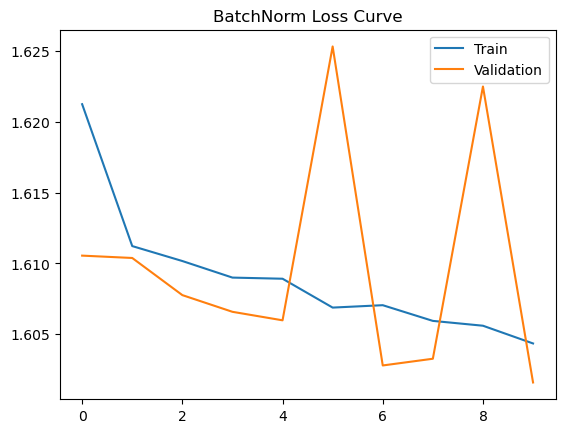

In [12]:
model = build_model(
    filters=[32,64,128],
    kernel_size=3,
    dropout=0.3,
    attention_units=128,
    batch_norm=True
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

results.append({
    "Experiment":"BatchNorm",
    "Modification":"Add Batch Normalization",
    "Train Loss":history.history["loss"][-1],
    "Validation Loss":history.history["val_loss"][-1],
    "Validation Accuracy":history.history["val_accuracy"][-1]
})

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("BatchNorm Loss Curve")
plt.legend(["Train","Validation"])
plt.show()

In [14]:
import pandas as pd

# Create results dataframe with extracted values
results_df = pd.DataFrame({
    "Experiment": [
        "Baseline",
        "No Dropout",
        "More Filters",
        "Attention 256",
        "BatchNorm"
    ],
    
    "Modification": [
        "None",
        "Remove Dropout",
        "Increase CNN filters",
        "Increase attention units",
        "Add Batch Normalization"
    ],
    
    "Train Loss": [
        1.6098,
        1.6098,
        1.6096,
        1.6096,
        1.6044
    ],
    
    "Validation Loss": [
        1.6094,
        1.6095,
        1.6094,
        1.6096,
        1.6016
    ],
    
    "Validation Accuracy": [
        0.2041,
        0.2021,
        0.2044,
        0.2044,
        0.2328
    ]
})

# Display dataframe
results_df

,Experiment,Modification,Train Loss,Validation Loss,Validation Accuracy
0,Baseline,None,1.6098,1.6094,0.2041
1,No Dropout,Remove Dropout,1.6098,1.6095,0.2021
2,More Filters,Increase CNN filters,1.6096,1.6094,0.2044
3,Attention 256,Increase attention units,1.6096,1.6096,0.2044
4,BatchNorm,Add Batch Normalization,1.6044,1.6016,0.2328


In [15]:
results_df.to_csv("results/tables/results_table.csv", index=False)

In [16]:
predictions = model.predict(X_val)

predicted_labels = np.argmax(predictions, axis=1)

print("First 10 predicted positions:", predicted_labels[:10] + 1)
print("First 10 true positions:", y_val[:10] + 1)

111/111 ━━━━━━━━━━━━━━━━━━━━ 103s 913ms/step
First 10 predicted positions: [5 1 5 5 2 1 5 1 5 5]
First 10 true positions: [5 4 5 4 1 1 1 5 4 3]


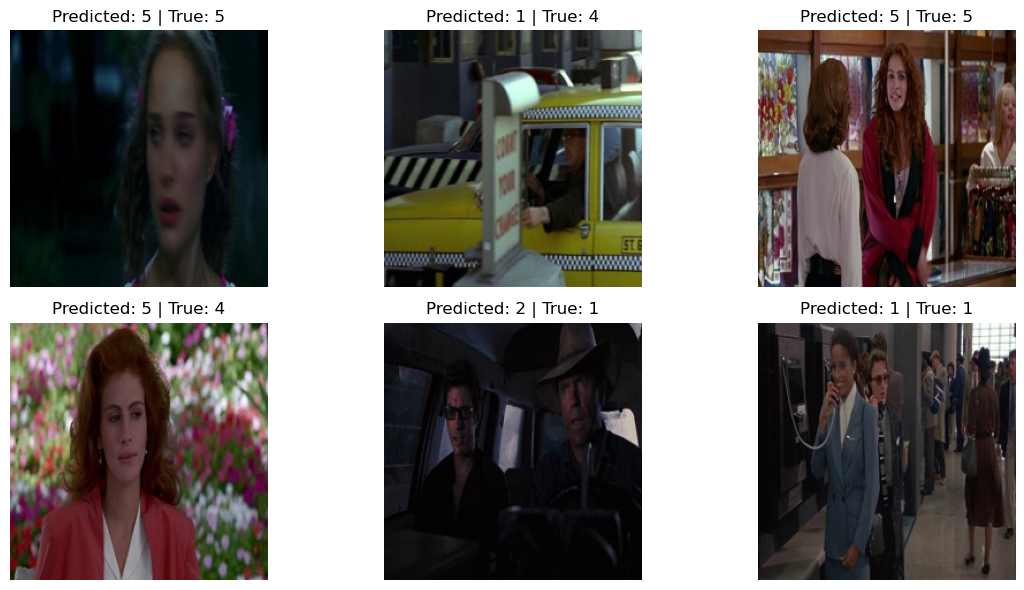

In [17]:
num_samples = 6

plt.figure(figsize=(12,6))

for i in range(num_samples):

    plt.subplot(2,3,i+1)

    plt.imshow(X_val[i])
    plt.axis("off")

    pred = predicted_labels[i] + 1
    true = y_val[i] + 1

    plt.title(f"Predicted: {pred} | True: {true}")

plt.tight_layout()
plt.show()